# Deterministic-average circuit QPINN with `torch.autograd`

This notebook is the simpler simulation counterpart of `QPINN_hyperoctahedral_chebyshev.ipynb`.  It keeps the same quantum-circuit QFM and the same $B_2$-symmetric screened Poisson problem, but it computes the average operator exactly by enumerating group elements and uses `torch.autograd` for the PDE residual.

The PDE is

$$
(-\Delta+\lambda)u(x)=q(x), \qquad x=(x_1,x_2)\in[-1,1]^2,
$$

with homogeneous Dirichlet boundary condition $u|_{\partial\Omega}=0$.  Let

$$
\phi_m(t)=\cos\left(\frac{m\pi t}{2}\right).
$$

The source is

$$
q(x_1,x_2)=
\phi_1(x_1)\phi_1(x_2)
+0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right],
$$

with analytical solution

$$
u_\star(x_1,x_2)=
\frac{\phi_1(x_1)\phi_1(x_2)}{\lambda+\pi^2/2}
+\frac{0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right]}{\lambda+5\pi^2/2}.
$$

The target solution is invariant under the hyperoctahedral group $B_2$, i.e. independent sign flips and coordinate permutations.  The exact averaged models are

$$
A_{\mathbb Z_2^2}f_\theta(x)=\frac{1}{4}\sum_{s\in\{\pm1\}^2}f_\theta(s\odot x),
$$

and

$$
A_{B_2}f_\theta(x)=\frac{1}{8}\sum_{\pi\in S_2}\sum_{s\in\{\pm1\}^2}f_\theta(s\odot x_\pi).
$$

This exact-average/autograd version is not the resource-efficient hardware estimator.  Its purpose is to cleanly test the modeling effect of the average operator before adding randomized encoding and parameter-shift sampling.

In [1]:
from __future__ import annotations

from collections import defaultdict
from copy import deepcopy
from itertools import permutations, product
from pathlib import Path
import os
import sys
import tempfile

import numpy as np
import torch

_MPL_CACHE = Path(tempfile.gettempdir()) / "matplotlib-cache"
_MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_CACHE))
_XDG_CACHE = Path(tempfile.gettempdir()) / "xdg-cache"
_XDG_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(_XDG_CACHE))

IS_NOTEBOOK = "ipykernel" in sys.modules
import matplotlib
if not IS_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_or_close_current_figure() -> None:
    if IS_NOTEBOOK:
        plt.show()
    else:
        plt.close()


USE_DOUBLE_PRECISION = False


def _candidate_dtypes(candidate: torch.device):
    if USE_DOUBLE_PRECISION and candidate.type != "mps":
        return torch.float64, torch.complex128
    return torch.float32, torch.complex64


def _complex_autograd_works(candidate: torch.device) -> bool:
    real_dt, complex_dt = _candidate_dtypes(candidate)
    try:
        theta = torch.tensor(0.37, dtype=real_dt, device=candidate, requires_grad=True)
        half = 0.5 * theta
        c = torch.cos(half)
        s = torch.sin(half)
        gate = torch.stack(
            [
                torch.stack([torch.complex(c, torch.zeros_like(c)), torch.complex(torch.zeros_like(s), -s)]),
                torch.stack([torch.complex(torch.zeros_like(s), -s), torch.complex(c, torch.zeros_like(c))]),
            ]
        ).to(complex_dt)
        loss = (gate.abs() ** 2).sum()
        loss.backward()
        return theta.grad is not None and torch.isfinite(theta.grad)
    except Exception as exc:
        print(f"Skipping {candidate.type}: complex autograd check failed ({exc}).")
        return False


def select_accelerated_device() -> torch.device:
    candidates = []
    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))
    candidates.append(torch.device("cpu"))

    for candidate in candidates:
        if _complex_autograd_works(candidate):
            return candidate
    return torch.device("cpu")


DEVICE = select_accelerated_device()
REAL_DTYPE, COMPLEX_DTYPE = _candidate_dtypes(DEVICE)
torch.set_default_dtype(REAL_DTYPE)

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)


def locate_paper_work_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "MSQE").exists() and cwd.name == "Paper_work":
        return cwd
    if (cwd / "Paper_work" / "MSQE").exists():
        return cwd / "Paper_work"
    for parent in cwd.parents:
        if (parent / "Paper_work" / "MSQE").exists():
            return parent / "Paper_work"
    return cwd


PAPER_WORK_DIR = locate_paper_work_dir()
FIGURE_DIR = PAPER_WORK_DIR / "MSQE" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device={DEVICE}, real dtype={REAL_DTYPE}, complex dtype={COMPLEX_DTYPE}")

Skipping mps: complex autograd check failed (The operator 'aten::complex.out' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.).
Using device=cpu, real dtype=torch.float32, complex dtype=torch.complex64


## Circuit QFM ansatz

The baseline circuit is a data re-uploading QFM.  Each upload block applies a trainable StronglyEntanglingLayer-style block followed by exponential Pauli encoding,

$$
R_X(\beta_j x_j)=\exp[-i\beta_jx_jX_j/2],
\qquad \beta_j=3^j .
$$

The trainable block applies `Rot` gates on all wires followed by a CNOT ring.  The scalar model output is a trainable affine readout of $\langle Z_0\rangle$, $\langle Z_1\rangle$, and $\langle Z_0Z_1\rangle$.

In [2]:
DIM = 2
N_QUBITS = 2
N_UPLOAD_LAYERS = 2
STRONG_LAYERS_PER_BLOCK = 1

EXP_BASE = 3.0
ENCODING_SCALE = 1.0
DIFF_GENERATOR_PER_LAYER = False

LAMBDA = 1.0
SOURCE_MODE_COEFFICIENTS = {
    (1, 1): 1.0,
    (1, 3): 0.3,
    (3, 1): 0.3,
}

TRAINING_STEPS = 60
INTERIOR_BATCH = 16
BOUNDARY_BATCH = 16
LR = 1.0e-2
BOUNDARY_WEIGHT = 10.0
INTERIOR_MARGIN = 0.94
GRAD_CLIP = 5.0

EVAL_GRID_N = 41

assert DIM == 2, "This benchmark cell is written for the B_2 screened-Poisson example."
assert N_QUBITS >= DIM, "The circuit uses one encoding wire per input coordinate."


In [3]:
_CNOT_GATHER_CACHE: dict[tuple[int, int, int, str], torch.Tensor] = {}


def as_1d(theta: torch.Tensor) -> torch.Tensor:
    return theta.reshape(1) if theta.ndim == 0 else theta


def complex_pair(real: torch.Tensor, imag: torch.Tensor) -> torch.Tensor:
    return torch.complex(real, imag).to(COMPLEX_DTYPE)


def rx_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    row0 = torch.stack([complex_pair(c, z), complex_pair(z, -s)], dim=-1)
    row1 = torch.stack([complex_pair(z, -s), complex_pair(c, z)], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def ry_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    row0 = torch.stack([complex_pair(c, torch.zeros_like(c)), complex_pair(-s, torch.zeros_like(s))], dim=-1)
    row1 = torch.stack([complex_pair(s, torch.zeros_like(s)), complex_pair(c, torch.zeros_like(c))], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def rz_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    row0 = torch.stack([complex_pair(c, -s), complex_pair(z, z)], dim=-1)
    row1 = torch.stack([complex_pair(z, z), complex_pair(c, s)], dim=-1)
    return torch.stack([row0, row1], dim=-2)


def rot_matrix(phi: torch.Tensor, theta: torch.Tensor, omega: torch.Tensor) -> torch.Tensor:
    return rz_matrix(omega) @ ry_matrix(theta) @ rz_matrix(phi)


def apply_single_qubit_gate(state: torch.Tensor, gate: torch.Tensor, wire: int) -> torch.Tensor:
    batch = state.shape[0]
    if gate.shape[0] == 1 and batch != 1:
        gate = gate.expand(batch, -1, -1)
    tensor = state.reshape(batch, *([2] * N_QUBITS))
    axis = wire + 1
    tensor = tensor.movedim(axis, -1)
    updated = torch.einsum("bij,b...j->b...i", gate, tensor)
    updated = updated.movedim(-1, axis)
    return updated.reshape(batch, 2**N_QUBITS)


def cnot_gather_index(n_qubits: int, control: int, target: int, device: torch.device) -> torch.Tensor:
    key = (n_qubits, control, target, device.type)
    if key in _CNOT_GATHER_CACHE:
        return _CNOT_GATHER_CACHE[key]

    gather = [0] * (2**n_qubits)
    for input_index in range(2**n_qubits):
        bits = [(input_index >> (n_qubits - 1 - q)) & 1 for q in range(n_qubits)]
        output_bits = bits[:]
        if bits[control] == 1:
            output_bits[target] ^= 1
        output_index = 0
        for bit in output_bits:
            output_index = (output_index << 1) | bit
        gather[output_index] = input_index

    tensor = torch.tensor(gather, dtype=torch.long, device=device)
    _CNOT_GATHER_CACHE[key] = tensor
    return tensor


def apply_cnot(state: torch.Tensor, control: int, target: int) -> torch.Tensor:
    gather = cnot_gather_index(N_QUBITS, control, target, state.device)
    return state[:, gather]


def apply_strongly_entangling_block(state: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    for sublayer in range(weights.shape[0]):
        for wire in range(N_QUBITS):
            phi, theta, omega = weights[sublayer, wire]
            state = apply_single_qubit_gate(state, rot_matrix(phi, theta, omega), wire)

        if N_QUBITS > 1:
            cnot_range = (sublayer % (N_QUBITS - 1)) + 1
            for control in range(N_QUBITS):
                target = (control + cnot_range) % N_QUBITS
                state = apply_cnot(state, control, target)
    return state


def initial_state(batch: int) -> torch.Tensor:
    state = torch.zeros(batch, 2**N_QUBITS, dtype=COMPLEX_DTYPE, device=DEVICE)
    state[:, 0] = torch.ones(batch, dtype=COMPLEX_DTYPE, device=DEVICE)
    return state


def z_feature_values() -> torch.Tensor:
    values = []
    for basis_index in range(2**N_QUBITS):
        bits = [(basis_index >> (N_QUBITS - 1 - q)) & 1 for q in range(N_QUBITS)]
        z0 = 1.0 if bits[0] == 0 else -1.0
        z1 = 1.0 if bits[1] == 0 else -1.0
        values.append([z0, z1, z0 * z1])
    return torch.tensor(values, dtype=REAL_DTYPE, device=DEVICE)


Z_FEATURE_VALUES = z_feature_values()

In [4]:
def group_transforms(x: torch.Tensor, group: str) -> list[torch.Tensor]:
    if group == "none":
        return [x]

    sign_patterns = list(product([-1.0, 1.0], repeat=DIM))

    if group == "signflip":
        return [
            x * torch.tensor(signs, dtype=x.dtype, device=x.device)
            for signs in sign_patterns
        ]

    if group == "hyperoctahedral":
        transformed = []
        for perm in permutations(range(DIM)):
            xp = x[:, perm]
            for signs in sign_patterns:
                transformed.append(xp * torch.tensor(signs, dtype=x.dtype, device=x.device))
        return transformed

    raise ValueError(f"Unknown group: {group}")


class ReuploadingStrongEntangleQFM(torch.nn.Module):
    def __init__(self, group: str, init_scale: float = 0.2):
        super().__init__()
        self.group = group
        weight_shape = (N_UPLOAD_LAYERS + 1, STRONG_LAYERS_PER_BLOCK, N_QUBITS, 3)
        self.weights = torch.nn.Parameter(
            init_scale * torch.randn(weight_shape, dtype=REAL_DTYPE, device=DEVICE)
        )
        self.readout_weights = torch.nn.Parameter(
            torch.tensor([0.5, 0.5, 0.1], dtype=REAL_DTYPE, device=DEVICE)
        )
        self.readout_bias = torch.nn.Parameter(torch.zeros((), dtype=REAL_DTYPE, device=DEVICE))
        self.output_scale = torch.nn.Parameter(torch.tensor(0.5, dtype=REAL_DTYPE, device=DEVICE))

    @staticmethod
    def encoding_beta(upload: int, wire: int) -> float:
        exponent = upload * N_QUBITS + wire if DIFF_GENERATOR_PER_LAYER else wire
        return EXP_BASE ** exponent

    def base_circuit(self, x: torch.Tensor) -> torch.Tensor:
        batch = x.shape[0]
        state = initial_state(batch)

        for upload in range(N_UPLOAD_LAYERS):
            state = apply_strongly_entangling_block(state, self.weights[upload])
            for wire in range(N_QUBITS):
                coordinate = wire % DIM
                beta = self.encoding_beta(upload, wire)
                angle = ENCODING_SCALE * beta * x[:, coordinate]
                state = apply_single_qubit_gate(state, rx_matrix(angle), wire)

        state = apply_strongly_entangling_block(state, self.weights[-1])
        probabilities = (state.abs() ** 2).real
        pauli_features = probabilities @ Z_FEATURE_VALUES
        expectation_readout = pauli_features @ self.readout_weights
        return self.readout_bias + self.output_scale * expectation_readout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        transformed_outputs = [self.base_circuit(xg) for xg in group_transforms(x, self.group)]
        return torch.stack(transformed_outputs, dim=0).mean(dim=0)


MODEL_SPECS = {
    "ordinary QFM": "none",
    "exact sign-flip QFM": "signflip",
    "exact B2 QFM": "hyperoctahedral",
}


def make_models() -> dict[str, ReuploadingStrongEntangleQFM]:
    torch.manual_seed(SEED)
    reference = ReuploadingStrongEntangleQFM(group="none")
    reference_state = deepcopy(reference.state_dict())

    models = {}
    for name, group in MODEL_SPECS.items():
        model = ReuploadingStrongEntangleQFM(group=group)
        model.load_state_dict(reference_state)
        models[name] = model
    return models

## Autograd QPINN loss

The empirical loss is

$$
\mathcal L(\theta)=
\frac{1}{N_\Omega}\sum_i
\left[(-\Delta+\lambda)u_\theta(x_i)-q(x_i)\right]^2
+\mu\frac{1}{N_{\partial\Omega}}\sum_i u_\theta(y_i)^2.
$$

Here the Laplacian is computed by differentiating the circuit output with respect to the physical input coordinates using `torch.autograd`.

In [5]:
def phi_mode(x: torch.Tensor, mode: int) -> torch.Tensor:
    return torch.cos(0.5 * mode * torch.pi * x)


def source_term(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2)
    return value


def analytical_solution(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        eigenvalue = (0.5 * torch.pi * m1) ** 2 + (0.5 * torch.pi * m2) ** 2
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2) / (LAMBDA + eigenvalue)
    return value


def laplacian(model: torch.nn.Module, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    u = model(x_req)
    grad_u = torch.autograd.grad(u.sum(), x_req, create_graph=True)[0]

    lap = torch.zeros_like(u)
    for dim in range(DIM):
        second = torch.autograd.grad(grad_u[:, dim].sum(), x_req, create_graph=True)[0][:, dim]
        lap = lap + second
    return lap, u


def physics_loss(model: torch.nn.Module, interior_x: torch.Tensor, boundary_x: torch.Tensor) -> tuple[torch.Tensor, dict[str, float]]:
    lap, u_interior = laplacian(model, interior_x)
    residual = -lap + LAMBDA * u_interior - source_term(interior_x)
    residual_loss = torch.mean(residual**2)

    u_boundary = model(boundary_x)
    boundary_loss = torch.mean(u_boundary**2)
    loss = residual_loss + BOUNDARY_WEIGHT * boundary_loss

    metrics = {
        "loss": float(loss.detach().cpu()),
        "residual": float(residual_loss.detach().cpu()),
        "boundary": float(boundary_loss.detach().cpu()),
    }
    return loss, metrics

In [6]:
def sample_interior(batch: int) -> torch.Tensor:
    return (2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0) * INTERIOR_MARGIN


def sample_boundary(batch: int) -> torch.Tensor:
    x = 2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0
    sides = torch.randint(0, 2 * DIM, (batch,), device=DEVICE)
    for dim in range(DIM):
        left = sides == 2 * dim
        right = sides == 2 * dim + 1
        x[left, dim] = -1.0
        x[right, dim] = 1.0
    return x


def train_model(name: str, model: torch.nn.Module) -> dict[str, list[float]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = defaultdict(list)

    for step in range(1, TRAINING_STEPS + 1):
        optimizer.zero_grad(set_to_none=True)
        interior_x = sample_interior(INTERIOR_BATCH)
        boundary_x = sample_boundary(BOUNDARY_BATCH)
        loss, metrics = physics_loss(model, interior_x, boundary_x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        for key, value in metrics.items():
            history[key].append(value)

        if step == 1 or step % max(1, TRAINING_STEPS // 5) == 0:
            print(
                f"{name:24s} step {step:4d}/{TRAINING_STEPS}: "
                f"loss={metrics['loss']:.3e}, residual={metrics['residual']:.3e}, boundary={metrics['boundary']:.3e}"
            )

    return dict(history)


def evaluation_grid(n: int = EVAL_GRID_N) -> tuple[torch.Tensor, np.ndarray, np.ndarray]:
    axis = torch.linspace(-1.0, 1.0, n, dtype=REAL_DTYPE, device=DEVICE)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack([x1.reshape(-1), x2.reshape(-1)], dim=1)
    return points, x1.detach().cpu().numpy(), x2.detach().cpu().numpy()


@torch.no_grad()
def evaluate_model(model: torch.nn.Module, points: torch.Tensor) -> torch.Tensor:
    return model(points).detach()


def relative_l2_error(pred: torch.Tensor, target: torch.Tensor) -> float:
    return float(torch.linalg.norm(pred - target).cpu() / torch.linalg.norm(target).cpu())


def symmetry_defects(model: torch.nn.Module, points: torch.Tensor) -> dict[str, float]:
    with torch.no_grad():
        base = model(points)
        sign_flip = model(points * torch.tensor([-1.0, 1.0], dtype=REAL_DTYPE, device=DEVICE))
        permutation = model(points[:, [1, 0]])
    return {
        "sign_flip_mse": float(torch.mean((base - sign_flip) ** 2).cpu()),
        "permutation_mse": float(torch.mean((base - permutation) ** 2).cpu()),
    }

In [7]:
models = make_models()
histories = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}")
    histories[model_name] = train_model(model_name, model)


Training ordinary QFM
ordinary QFM             step    1/60: loss=1.249e+01, residual=1.222e+01, boundary=2.666e-02
ordinary QFM             step   12/60: loss=2.903e+00, residual=2.847e+00, boundary=5.603e-03
ordinary QFM             step   24/60: loss=3.608e-01, residual=3.447e-01, boundary=1.612e-03
ordinary QFM             step   36/60: loss=1.843e-01, residual=1.722e-01, boundary=1.218e-03
ordinary QFM             step   48/60: loss=1.799e-01, residual=1.685e-01, boundary=1.137e-03
ordinary QFM             step   60/60: loss=1.865e-01, residual=1.766e-01, boundary=9.842e-04

Training exact sign-flip QFM
exact sign-flip QFM      step    1/60: loss=1.124e+01, residual=1.117e+01, boundary=7.639e-03
exact sign-flip QFM      step   12/60: loss=1.508e+00, residual=1.446e+00, boundary=6.163e-03
exact sign-flip QFM      step   24/60: loss=3.462e-01, residual=3.402e-01, boundary=6.040e-04
exact sign-flip QFM      step   36/60: loss=2.013e-01, residual=1.902e-01, boundary=1.101e-03
exact s

In [8]:
grid_points, grid_x1, grid_x2 = evaluation_grid()
target = analytical_solution(grid_points).detach()
target_grid = target.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)

predictions = {}
errors = {}
symmetry = {}

for model_name, model in models.items():
    pred = evaluate_model(model, grid_points)
    predictions[model_name] = pred.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)
    errors[model_name] = relative_l2_error(pred, target)
    symmetry[model_name] = symmetry_defects(model, grid_points)

print("Relative L2 errors")
for model_name, error in errors.items():
    print(f"  {model_name:24s}: {error:.4e}")

print("\nSymmetry defects")
for model_name, defects in symmetry.items():
    print(
        f"  {model_name:24s}: sign-flip MSE={defects['sign_flip_mse']:.3e}, "
        f"permutation MSE={defects['permutation_mse']:.3e}"
    )

Relative L2 errors
  ordinary QFM            : 5.6911e-01
  exact sign-flip QFM     : 5.2113e-01
  exact B2 QFM            : 1.1239e-01

Symmetry defects
  ordinary QFM            : sign-flip MSE=1.153e-04, permutation MSE=6.356e-04
  exact sign-flip QFM     : sign-flip MSE=7.778e-18, permutation MSE=1.808e-03
  exact B2 QFM            : sign-flip MSE=2.163e-17, permutation MSE=3.159e-17


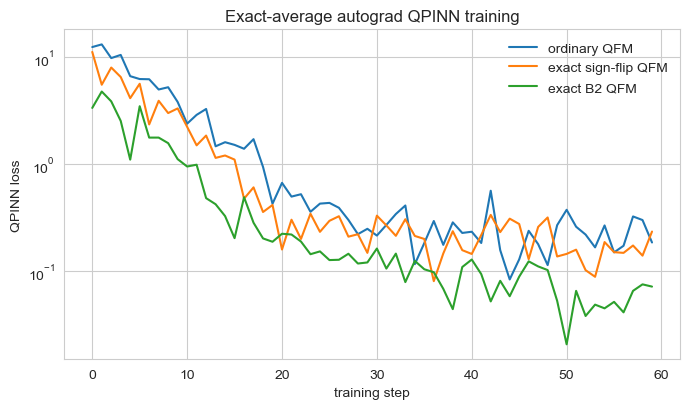

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_training_loss.png


In [9]:
plt.figure(figsize=(7.0, 4.2))
for model_name, history in histories.items():
    plt.semilogy(history["loss"], label=model_name)
plt.xlabel("training step")
plt.ylabel("QPINN loss")
plt.title("Exact-average autograd QPINN training")
plt.legend(frameon=False)
plt.tight_layout()
training_path = FIGURE_DIR / "qpinn_b2_autograd_training_loss.png"
plt.savefig(training_path, dpi=220)
show_or_close_current_figure()
print(f"saved {training_path}")

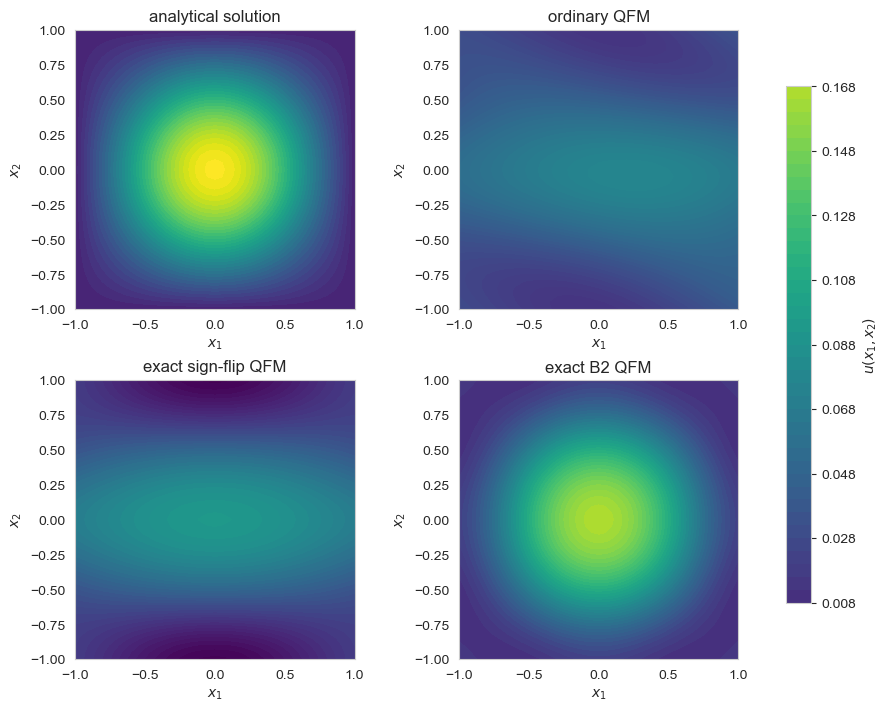

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_solution_comparison.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0), constrained_layout=True)
panels = [("analytical solution", target_grid)] + list(predictions.items())

vmin = min(np.min(panel) for _, panel in panels)
vmax = max(np.max(panel) for _, panel in panels)

for ax, (title, values) in zip(axes.ravel(), panels):
    image = ax.contourf(grid_x1, grid_x2, values, levels=40, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, label="$u(x_1,x_2)$")
solution_path = FIGURE_DIR / "qpinn_b2_autograd_solution_comparison.png"
plt.savefig(solution_path, dpi=220)
show_or_close_current_figure()
print(f"saved {solution_path}")

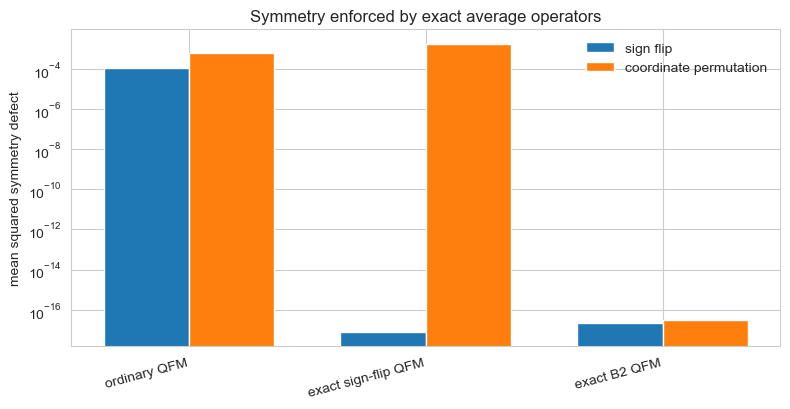

saved /Users/letao/DataSpellProjects/quantum-fourier-expressivity/Paper_work/MSQE/figures/qpinn_b2_autograd_symmetry_metrics.png


In [11]:
labels = list(symmetry.keys())
sign_values = [symmetry[name]["sign_flip_mse"] for name in labels]
perm_values = [symmetry[name]["permutation_mse"] for name in labels]

xpos = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(8.0, 4.2))
plt.bar(xpos - width / 2, sign_values, width, label="sign flip")
plt.bar(xpos + width / 2, perm_values, width, label="coordinate permutation")
plt.yscale("log")
plt.xticks(xpos, labels, rotation=15, ha="right")
plt.ylabel("mean squared symmetry defect")
plt.title("Symmetry enforced by exact average operators")
plt.legend(frameon=False)
plt.tight_layout()
symmetry_path = FIGURE_DIR / "qpinn_b2_autograd_symmetry_metrics.png"
plt.savefig(symmetry_path, dpi=220)
show_or_close_current_figure()
print(f"saved {symmetry_path}")

## Interpretation

This notebook computes $Af_\theta$ directly, so the sign-flip and $B_2$ models are exact averaged predictors in simulation.  The symmetry-defect plot should therefore show nearly zero sign-flip defect for the sign-flip model, and nearly zero sign-flip and permutation defects for the $B_2$ model, up to floating-point error.

This version is useful as the first-stage simulation baseline.  It verifies the modeling effect of the average operator without the additional Monte Carlo variance from randomized encoding and without the computational overhead of manual parameter-shift training.